In [7]:
# imports

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [8]:

df = pd.DataFrame(columns=["Job Name", "Slurm Job ID", "Slurm Nodes", "Slurm Node Count", "Slurm NTASKS", "Slurm CPUs per Task", "Slurm Memory per Node", "Slurm Time Limit", "Slurm Partition", "Slurm Account", "INIT_MODE", "RADIUS", "INIT_DEPTH", "TOTAL_STEPS", "SAVE_EVERY", "TARGET_WIDTH", "TARGET_HEIGHT", "CHUNK_SIZE", "MPI_RANKS", "IO_MODE", "MPI_SYNC_MODE", "RANK_GRID_X", "RANK_GRID_Z", "OVERWRITE_OUTPUT", "SKIP_RENDERING", "SKIP_COMPILE", "FFMPEG_THREADS", "RENDER_CPUS", "REDUCED_HEIGHT", "HEIGHT_MIN", "Preparation (s)", "Compilation (s)", "Solving (s)", "Top view rendering (s)", "Slice full height rendering (s)", "Slice reduced height rendering (s)", "Top view video (s)", "Slice full height video (s)", "Combined video 1:1 (s)", "Combined video 16:9 (s)", "Total (s)"])

for file in os.listdir("/hpcwork/thes2181/mini_app/"):
    # check if file is a directory
    if os.path.isdir(os.path.join("/hpcwork/thes2181/mini_app/", file)):
        if "d2000.0" in file:
            info_file = os.path.join(os.path.join("/hpcwork/thes2181/mini_app/", file), "timing_and_parameters.txt")
            if os.path.isfile(info_file):
                # Looks something like this:
                """
Job Name: circle_r120_d2000.0_s1000000_2160x1080_c23mm_16n_96t_1c__rank0_gather_none
Slurm Job ID: 65324502
Slurm Nodes: n23m[0077,0147,0162-0163,0230-0231,0363-0364],r23m[0029,0035,0106,0115,0175,0185,0187,0190]
Slurm NTASKS: 96
Slurm CPUs per Task: 1
Slurm Memory per Node: N/A
Slurm Time Limit: N/A
Slurm Partition: c23mm
Slurm Account: N/A

Parameters:
INIT_MODE: circle
RADIUS: 120
INIT_DEPTH: 2000.0
TOTAL_STEPS: 1000000
SAVE_EVERY: 100
TARGET_WIDTH: 2160
TARGET_HEIGHT: 1080
CHUNK_SIZE: 60
MPI_RANKS: 96
IO_MODE: rank0_gather
MPI_SYNC_MODE: none
RANK_GRID_X: 0
RANK_GRID_Z: 0
OVERWRITE_OUTPUT: 1
SKIP_RENDERING: 0
SKIP_COMPILE: 0
FFMPEG_THREADS: 16
RENDER_CPUS: 96
REDUCED_HEIGHT: 135
HEIGHT_MIN: 40

Timings (seconds):
Preparation: 10
Compilation: 3
Solving: 2474
Top view rendering: 238
Slice full height rendering: 248
Slice reduced height rendering: 238
Top view video: 482
Slice full height video: 378
Combined video 1:1: 341
Combined video 16:9: 305
Total: 4717
                """
                
                # We want to extract all the information from the info_file and add it to the DataFrame df
                row_data = {}
                
                with open(info_file, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if "Job Name:" in line:
                            #Job Name: circle_r120_d2000.0_s1000000_2160x1080_c23mm_16n_96t_1c__rank0_gather_none
                            # the _16n_ here indicates 16 nodes, we want to extract that and put it in the Slurm Node Count column
                            row_data["Slurm Node Count"] = re.search(r'_(\d+)n_', line).group(1)
                        if ':' in line and line and not line.startswith('Parameters') and not line.startswith('Timings'):
                            key, value = line.split(':', 1)
                            key = key.strip()
                            value = value.strip()
                            
                            # Map timing keys to column names with (s) suffix
                            if key in ["Preparation", "Compilation", "Solving", "Top view rendering", 
                                       "Slice full height rendering", "Slice reduced height rendering",
                                       "Top view video", "Slice full height video", "Combined video 1:1", 
                                       "Combined video 16:9", "Total"]:
                                col_name = f"{key} (s)"
                            else:
                                col_name = key
                            
                            row_data[col_name] = value
                
                # Add the row to the DataFrame
                df = pd.concat([df, pd.DataFrame([row_data])], ignore_index=True)
                
    # Print the DataFrame
print(df)


                                            Job Name Slurm Job ID  \
0  circle_r120_d2000.0_s1000000_2160x1080_c23mm_2...     65324477   
1  circle_r120_d2000.0_s1000000_2160x1080_c23mm_1...     65324507   
2  circle_r120_d2000.0_s1000000_2160x1080_c23mm_1...     65324502   
3  circle_r120_d2000.0_s1000000_2160x1080_c23mm_2...     65324522   
4  circle_r120_d2000.0_s1000000_2160x1080_c23mm_1...     65324461   
5  circle_r120_d2000.0_s1000000_2160x1080_c23mm_8...     65324500   
6  circle_r120_d2000.0_s1000000_2160x1080_c23mm_1...     65324570   
7  circle_r120_d2000.0_s1000000_2160x1080_c23mm_4...     65324498   
8  circle_r120_d2000.0_s1000000_2160x1080_c23mm_8...     65324569   

                                         Slurm Nodes Slurm Node Count  \
0                                    n23m[0217,0409]                2   
1                                           n23m0364                1   
2  n23m[0077,0147,0162-0163,0230-0231,0363-0364],...               16   
3                

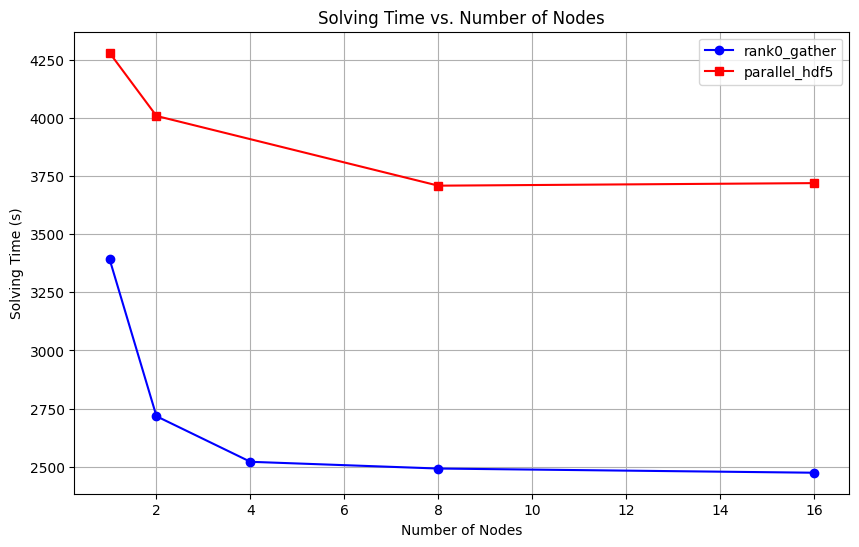

In [11]:
# Let's plot the solving time on the y-axis and the amount of nodes on the x-axis
# Separate lines for each IO_MODE
plt.figure(figsize=(10, 6))

# Filter data for each IO_MODE
rank0_gather = df[df["IO_MODE"] == "rank0_gather"].copy()
parallel_hdf5 = df[df["IO_MODE"] == "parallel_hdf5"].copy()

# Convert to numeric for proper sorting and plotting
rank0_gather["Slurm Node Count"] = pd.to_numeric(rank0_gather["Slurm Node Count"], errors='coerce')
rank0_gather["Solving (s)"] = pd.to_numeric(rank0_gather["Solving (s)"], errors='coerce')
parallel_hdf5["Slurm Node Count"] = pd.to_numeric(parallel_hdf5["Slurm Node Count"], errors='coerce')
parallel_hdf5["Solving (s)"] = pd.to_numeric(parallel_hdf5["Solving (s)"], errors='coerce')

# Sort after converting to numeric
rank0_gather = rank0_gather.sort_values("Slurm Node Count")
parallel_hdf5 = parallel_hdf5.sort_values("Slurm Node Count")

# Plot lines
plt.plot(rank0_gather["Slurm Node Count"], rank0_gather["Solving (s)"], color='blue', marker='o', label='rank0_gather')
plt.plot(parallel_hdf5["Slurm Node Count"], parallel_hdf5["Solving (s)"], color='red', marker='s', label='parallel_hdf5')

plt.title("Solving Time vs. Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Solving Time (s)")
plt.legend()
plt.grid()
plt.show()
